# <center> <img src="figs/LogoUFSCar.jpg" alt="Logo UFSCar" width="110" align="left"/>  <br/> <center>Universidade Federal de São Carlos (UFSCar)<br/><font size="4"> Departamento de Computação, campus Sorocaba</center></font>
</p>

<font size="4"><center><b>Disciplina: Processamento de Linguagem Natural</b></center></font>

<font size="3"><center>Prof. Dr. Tiago A. Almeida</center></font>

## <center>Projeto Final — Classificação Automática de Documentos Jurídicos</center>

**Nome**: Anderson Cristiano Sassaki Gonçalves

**RA**: 821675

**Nome**: Lorenzo Grippo Chiachio

**RA**: 823917

---
Este notebook desenvolve um pipeline completo para classificar documentos jurídicos da base VICTOR/STF nas categorias Acórdão, Agravo de Recurso Extraordinário, Despacho, Recurso Extraordinário e Sentença. A avaliação prioriza `f1_macro`, adequada ao possível desbalanceamento entre as classes.

O desenvolvimento está organizado em oito seções:

1. Análise de dados;
2. Pré-processamento e limpeza;
3. Representação computacional;
4. Tarefas básicas de PLN;
5. Modelos de classificação clássicos;
6. Modelos profundos de categorização;
7. Adaptação de modelos de linguagem;
8. Análise de resultados.


---
## Preparação do ambiente

As células seguintes verificam as dependências, definem os diretórios do projeto, importam as funções implementadas em `scripts/` e selecionam automaticamente o melhor dispositivo disponível (`cuda`, `mps` ou `cpu`). Essa preparação é comum a todas as etapas e, por isso, não faz parte da numeração do pipeline.


In [1]:
import importlib.util
import subprocess
import sys

BASE_MODULES = ["pandas", "numpy", "sklearn", "matplotlib", "seaborn", "joblib"]
ADVANCED_MODULES = ["torch", "transformers", "datasets", "sentence_transformers", "accelerate"]

missing_base = [pkg for pkg in BASE_MODULES if importlib.util.find_spec(pkg) is None]
if missing_base:
    print("Instalando dependências base ausentes:", missing_base)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"])
else:
    print("Dependências base já disponíveis.")

missing_advanced = [pkg for pkg in ADVANCED_MODULES if importlib.util.find_spec(pkg) is None]
if missing_advanced:
    print("Instalando dependências avançadas ausentes:", missing_advanced)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements-advanced.txt"])
else:
    print("Dependências avançadas já disponíveis.")

importlib.invalidate_caches()
print("Ambiente pronto para executar o pipeline completo.")


Instalando dependências base ausentes: ['pandas', 'numpy', 'sklearn', 'matplotlib', 'seaborn', 'joblib']
Instalando dependências avançadas ausentes: ['torch', 'transformers', 'datasets', 'sentence_transformers', 'accelerate']
Ambiente pronto para executar o pipeline completo.


In [2]:
from pathlib import Path
import sys

import pandas as pd

PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
MODEL_DIR = PROJECT_DIR / "models"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

sys.path.append(str((PROJECT_DIR / "scripts").resolve()))

from analise_exploratoria import (
    add_text_statistics,
    get_top_terms,
    load_competition_data,
    plot_class_distribution,
    plot_text_length_distribution,
    plot_top_terms,
    summarize_dataset,
    validate_schema,
    split_labeled_unlabeled,
)
from preprocessamento import (
    CLASS_NAMES,
    TextPreprocessConfig,
    add_clean_text_column,
    extract_basic_nlp_features,
    extract_legal_signal_features,
)
from experimentos import (
    ExperimentConfig,
    auto_runtime_profile,
    build_embedding_classifier_zoo,
    build_sentence_embedding_matrix,
    build_chunked_sentence_embedding_matrix,
    build_sparse_model_zoo,

    build_training_set_with_pseudo_labels,
    cross_validate_best_models,

    detect_label_issues_with_cv,
    evaluate_embedding_classifier,
    evaluate_model_zoo,
    fine_tune_transformer_classifier,
    fit_embedding_classifier_on_full_train,
    fit_model_on_full_train,
    generate_embedding_submission,
    generate_submission,
    generate_transformer_submission,

    pseudo_label_unlabeled_samples,
    save_model,
    select_best_model,
    transformer_candidate_models,
)
from analise_resultados import (
    classification_report_frame,
    plot_confusion_matrix,
    plot_metric_comparison,
    rank_results,
    save_results_table,
)

pd.set_option("display.max_colwidth", 160)

runtime_profile = auto_runtime_profile(prefer_transformer=True)
print("Diretório do projeto:", PROJECT_DIR)
print("Perfil automático:", runtime_profile["notes"])
display(pd.DataFrame([
    {
        "device": runtime_profile["device"],
        "advanced_available": runtime_profile["advanced_available"],
        "classical_model_zoo": runtime_profile["classical_model_zoo"],
        "run_classical_baselines": runtime_profile["run_classical_baselines"],
        "run_embeddings": runtime_profile["run_embeddings"],
        "run_transformer": runtime_profile["run_transformer"],
        "batch_transformer": runtime_profile["transformer_batch_size"],
        "max_length_transformer": runtime_profile["transformer_max_length"],
    }
]))


Diretório do projeto: c:\Users\lorenzo.chiachio\Documents\Pessoal\BCC\7-semestre\pln\Projeto\COURT\template-implementacao
Perfil automático: Complete pipeline enabled automatically on cpu.


,device,advanced_available,classical_model_zoo,run_classical_baselines,run_embeddings,run_transformer,batch_transformer,max_length_transformer
0,cpu,True,full,True,True,True,1,512


## 1. Análise de dados

Nesta seção, os arquivos `train.csv`, `test.csv` e `sample_submission.csv` são carregados e validados. Amostras com rótulos fora do intervalo de `0` a `4` são separadas para possível pseudo-rotulagem posterior.

A análise exploratória examina:

- distribuição das classes;
- dados ausentes;
- comprimento dos documentos;
- termos mais frequentes por categoria.

Esses resultados orientam o uso de `f1_macro`, balanceamento de classes, n-gramas robustos a OCR e estratégias para textos longos.


In [6]:
train_df, test_df, sample_df = load_competition_data(DATA_DIR)
schema_report = validate_schema(train_df, test_df, sample_df)
train_labeled, train_unlabeled = split_labeled_unlabeled(train_df)

print(f"Total no train.csv: {len(train_df)}")
print(f"Amostras rotuladas válidas: {len(train_labeled)}")
print(f"Amostras sem rótulo válido (Category=-1 ou fora de 0..4): {len(train_unlabeled)}")
print(f"Amostras de teste: {len(test_df)}")

print("Classes usadas no treinamento:")
for label, name in CLASS_NAMES.items():
    print(f"{label}: {name}")

schema_report


Total no train.csv: 22680
Amostras rotuladas válidas: 20412
Amostras sem rótulo válido (Category=-1 ou fora de 0..4): 2268
Amostras de teste: 2521
Classes usadas no treinamento:
0: Acordao
1: Agravo de Recurso Extraordinario (ARE)
2: Despacho
3: Recurso Extraordinario (RE)
4: Sentenca


{'train_shape': (22680, 3),
 'test_shape': (2521, 2),
 'sample_shape': (15, 2),
 'train_missing_columns': [],
 'test_missing_columns': [],
 'sample_missing_columns': [],
 'train_nulls': {'Id': 0, 'Body': 0, 'Category': 0},
 'test_nulls': {'Id': 0, 'Body': 0},
 'duplicated_train_ids': 0,
 'duplicated_test_ids': 0,
 'invalid_category_count': 2268,
 'invalid_category_examples': [{'Id': 9716, 'Category': -1},
  {'Id': 25112, 'Category': -1},
  {'Id': 11274, 'Category': -1},
  {'Id': 20985, 'Category': -1},
  {'Id': 23109, 'Category': -1},
  {'Id': 21386, 'Category': -1},
  {'Id': 21334, 'Category': -1},
  {'Id': 20980, 'Category': -1},
  {'Id': 18398, 'Category': -1},
  {'Id': 7787, 'Category': -1}]}

In [7]:
display(train_labeled.head())
display(test_df.head())
if sample_df is not None:
    display(sample_df.head())

,Id,Body,Category
0,12980,"{""conclusÃ£o diante exposto recorrente espera confia que recurso ora arrazoado interposto com fulcro ARTIGO_102 iii constituiÃ§Ã£o federal serÃ¡ admitido co...",3
1,9775,"{""ARTIGO_55 gecen a gacen serÃ£o devidas aos titulares dos empregos cargos pÃºblicos que tratam ARTIGO_53 desta lei que carÃ¡ter permanente realizarem ativi...",3
2,16061,"{""seguir desacerto decisÃ£o que negou seguimento recurso extraordinÃ¡rio equÃ­voco decisÃ£o discutida constitucionalidade prazo mÃ­nimo anos para que impedi...",1
3,22984,"{""advocacia geral uniÃ£o procuradoria uniÃ£o paraÃ­ba geral isonomia contido ARTIGO_5Âº caput cf e preceito que garante isonomia entre servidores ativos ina...",3
4,5716,"{""ministÃ©rio fazenda procuradoria geral fazenda nacional procuradoria seccional fazenda nacional campina grande paga pelo inss modo garantir empregado manu...",3


,Id,Body
0,9213,"{""um regime democrática direito qual seja da separação dos poderes recurso inominado parte autora improvido sem condenação ônus sucumbenciais por força conc..."
1,17427,"{""controvérsia fato que requerente participante rpps junto prefeitura municipal roca sales desde que valores atinentes aposentadorias rurais não são essenci..."
2,4753,"{""advocacia geral união procuradoria união paraíba excelentíssimo senhor juiz federal presidente turma recursal dos juizados especiais paraíba união por sua..."
3,4640,"{""advocacia geral união procuradoria união estado paraíba divisão atuação nos juizados especiais federais ARTIGO_169 despesa com pessoal ativo inativo união..."
4,20412,"{""ministério fazenda procuradoria geral fazenda nacional procuradoria seccional fazenda nacional campina grande pede deferimento campina grande de dezembro ..."


,Id,Category
0,7271,3
1,861,4
2,5391,0
3,5192,3
4,5735,1


In [8]:
eda = summarize_dataset(train_labeled)
train_stats = eda["data_with_stats"]

print("Distribuição de classes")
display(eda["class_distribution"])

print("Valores ausentes")
display(eda["missing_summary"])

print("Resumo de tamanho por classe")
display(eda["length_summary"])


Distribuição de classes


,Category,count,percent
3,0,665,3.257888
1,1,3529,17.288850
4,2,439,2.150696
0,3,12876,63.080541
2,4,2903,14.222026


Valores ausentes


,missing
Id,0
Body,0
Category,0


Resumo de tamanho por classe


n_chars                                                           \
            count         mean         std    min      25%     50%     75%   
Category                                                                     
0           665.0  2011.908271  907.395586  155.0  1292.00  2119.0  2615.0   
1          3529.0  1578.096345  735.338974    4.0  1086.00  1456.0  2016.0   
2           439.0  1195.735763  852.372715  113.0   443.00  1154.0  1508.5   
3         12876.0  1746.595216  704.201052   33.0  1360.75  1712.0  2124.0   
4          2903.0  2046.951085  771.020978   94.0  1602.00  1931.0  2640.0   

                  n_words              ...               unique_word_ratio  \
             max    count        mean  ...    75%    max             count   
Category                               ...                                   
0         4798.0    665.0  251.539850  ...  326.0  576.0             665.0   
1         5702.0   3529.0  195.200057  ...  248.0  685.0            3529.0   
2         6867.0    439.0  149.036446  ...  186.5  844.0             439.0   
3         5923.0  12876.0  213.882883  ...  260.0  781.0           12876.0   
4         6448.0   2903.0  254.391319  ...  324.0  837.0            2903.0   

                                                                           
              mean       std       min       25%       50%       75%  max  
Category                                                                   
0         0.773313  0.095599  0.493671  0.719008  0.772727  0.827206  1.0  
1         0.765190  0.088360  0.287037  0.708812  0.768293  0.821138  1.0  
2         0.771077  0.125442  0.496445  0.655629  0.750000  0.867839  1.0  
3         0.748295  0.080344  0.311450  0.700472  0.748503  0.796667  1.0  
4         0.712588  0.096364  0.322464  0.648438  0.698551  0.768298  1.0  

[5 rows x 24 columns]

(<Figure size 1400x400 with 2 Axes>,
 array([<Axes: title={'center': 'Distribuicao de n_words'}, xlabel='n_words', ylabel='Count'>,
        <Axes: title={'center': 'n_words por categoria'}, xlabel='Categoria', ylabel='n_words'>],
       dtype=object))

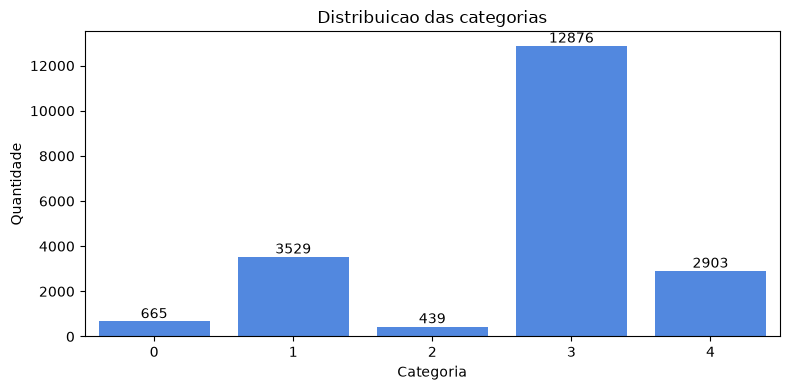

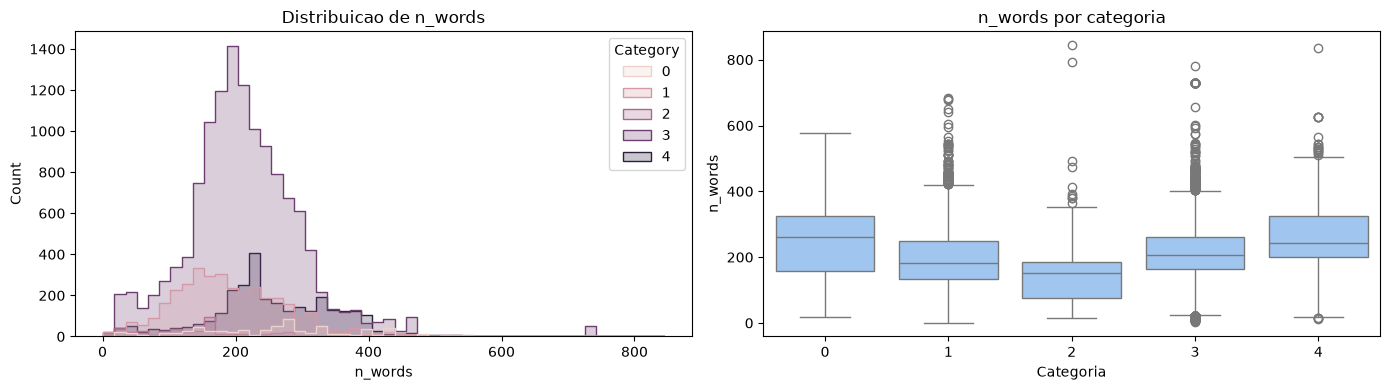

In [9]:
plot_class_distribution(eda["class_distribution"])
plot_text_length_distribution(train_stats, metric="n_words")

,Category,rank,term,mean_tfidf
0,0,1,que,0.036901
1,0,2,dos,0.031524
2,0,3,nã,0.029472
3,0,4,por,0.026014
4,0,5,para,0.024199
5,0,6,nos,0.023587
6,0,7,federal,0.023571
7,0,8,recurso,0.022599
8,0,9,com,0.022064
9,0,10,relator,0.021283


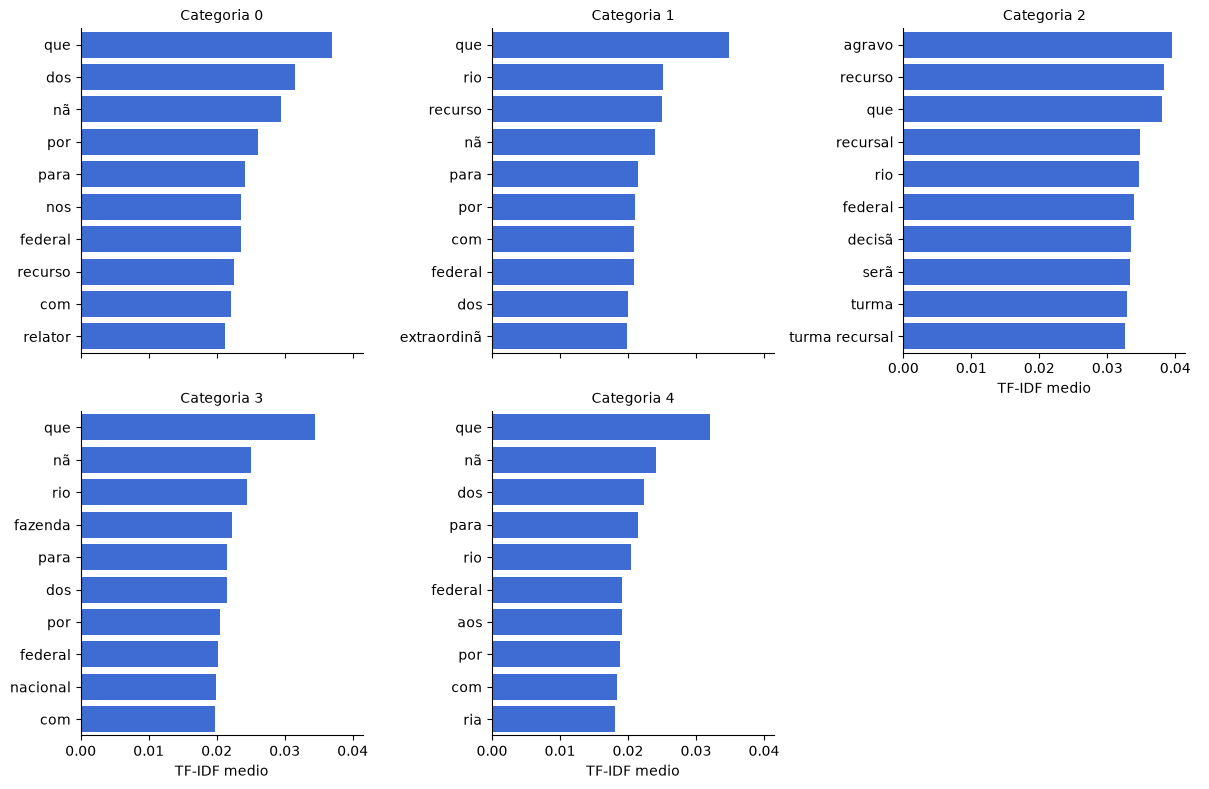

In [10]:
top_terms = get_top_terms(train_labeled, n_terms=12)
display(top_terms.head(30))
plot_top_terms(top_terms, n_terms=10)

## 2. Pré-processamento e limpeza

Os documentos podem conter ruídos de OCR, quebras artificiais, hifenização, assinaturas digitais, números processuais e referências legais em formatos variados. A limpeza produz a coluna `Body_clean`, usada como interface estável entre os dados e os modelos.

As principais operações são normalização de caixa e acentos, remoção de URLs e e-mails, padronização de referências jurídicas, datas e valores, além da filtragem de tokens muito curtos. As stopwords são preservadas porque fórmulas funcionais podem caracterizar o tipo de documento jurídico.


### Diagnóstico do conjunto de treinamento

A inspeção do `train.csv` mostrou que a preparação dos dados não se limita à limpeza de caracteres. O conjunto contém **22.680 amostras**, mas **2.268** delas possuem `Category = -1` e não podem ser usadas diretamente como exemplos supervisionados.

Entre as **20.412 amostras com rótulo válido**, foram observados:

- forte desbalanceamento: a classe `3` representa **63,08%** das amostras, enquanto as classes `0` e `2` correspondem a apenas **3,26%** e **2,15%**;
- **2.272 grupos de textos exatamente repetidos**, abrangendo **12.115 linhas**;
- **21 grupos de textos idênticos com classes válidas diferentes**, totalizando **58 linhas**. Os conflitos aparecem entre as classes `1` e `3` e entre as classes `2` e `4`;
- ruídos típicos de extração de documentos jurídicos, como problemas de codificação, quebras artificiais, hifenização, referências processuais e variações de escrita;
- documentos extensos, que exigem atenção especial nas representações neurais com janela limitada.

Uma duplicata não é necessariamente um erro: ela pode representar conteúdo legítimo repetido em um processo. Já um texto idêntico associado a classes diferentes constitui uma ambiguidade que não pode ser resolvida apenas pelo conteúdo textual. Por isso, o pipeline evita descartar ou sobrescrever esses exemplos de maneira indiscriminada.


In [11]:
preprocess_config = TextPreprocessConfig(
    lowercase=True,
    strip_accents=True,
    normalize_legal_refs=True,
    remove_urls_emails=True,
    remove_stopwords=False,
    min_token_len=2,
    keep_digits=False,
)

train_clean = add_clean_text_column(train_labeled, config=preprocess_config)
test_clean = add_clean_text_column(test_df, config=preprocess_config)

train_clean[["Id", "Category", "Body", "Body_clean"]].head(3)


,Id,Category,Body,Body_clean
0,12980,3,"{""conclusÃ£o diante exposto recorrente espera confia que recurso ora arrazoado interposto com fulcro ARTIGO_102 iii constituiÃ§Ã£o federal serÃ¡ admitido co...",conclusa diante exposto recorrente espera confia que recurso ora arrazoado interposto com fulcro artigo_ iii constituia artigo federal sera admitido conheci...
1,9775,3,"{""ARTIGO_55 gecen a gacen serÃ£o devidas aos titulares dos empregos cargos pÃºblicos que tratam ARTIGO_53 desta lei que carÃ¡ter permanente realizarem ativi...",artigo_ gecen gacen sera devidas aos titulares dos empregos cargos pa blicos que tratam artigo_ desta lei que cara ter permanente realizarem atividades comb...
2,16061,1,"{""seguir desacerto decisÃ£o que negou seguimento recurso extraordinÃ¡rio equÃ­voco decisÃ£o discutida constitucionalidade prazo mÃ­nimo anos para que impedi...",seguir desacerto decisa que negou seguimento recurso extraordina rio equa voco decisa discutida constitucionalidade prazo ma nimo anos para que impedimento ...


(<Figure size 1400x400 with 2 Axes>,
 array([<Axes: title={'center': 'Distribuicao de n_words'}, xlabel='n_words', ylabel='Count'>,
        <Axes: title={'center': 'n_words por categoria'}, xlabel='Categoria', ylabel='n_words'>],
       dtype=object))

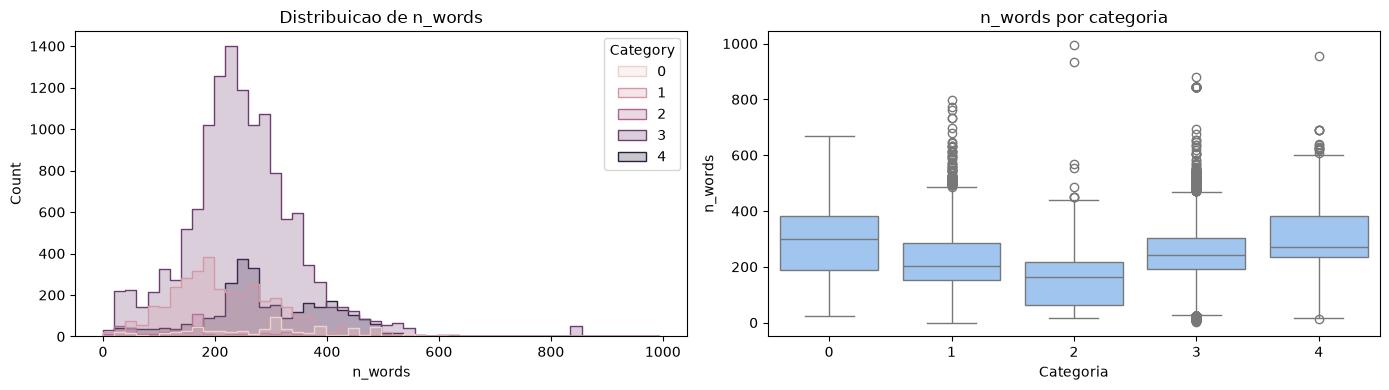

In [12]:
train_clean_stats = add_text_statistics(train_clean, text_col="Body_clean")
plot_text_length_distribution(train_clean_stats, metric="n_words")

### Estratégias adotadas pelo código

O pipeline trata esses problemas de forma conservadora:

1. **Separação de amostras sem rótulo válido:** `split_labeled_unlabeled` impede que linhas com `Category = -1` contaminem a avaliação supervisionada. Elas são preservadas para uma etapa posterior de pseudo-rotulagem.
2. **Normalização textual:** `add_clean_text_column` produz `Body_clean`, padronizando caixa e acentos, removendo URLs e e-mails, normalizando referências jurídicas e descartando tokens muito curtos. As stopwords são mantidas porque fórmulas funcionais podem ajudar a caracterizar documentos jurídicos.
3. **Verificação do efeito da limpeza:** as estatísticas de comprimento são recalculadas sobre `Body_clean`, permitindo observar como a normalização alterou os documentos antes da modelagem.
4. **Auditoria posterior de rótulos:** depois dos baselines clássicos, `detect_label_issues_with_cv` procura exemplos cujo rótulo diverge de previsões fora da dobra com confiança mínima de `0,85`. A correção automática só ocorre quando a confiança chega a `0,97`.
5. **Pseudo-rotulagem restritiva:** amostras originalmente marcadas com `-1` só entram no treinamento final quando o modelo atribui uma classe com confiança mínima de `0,92`.
6. **Desbalanceamento:** a seleção dos modelos prioriza `f1_macro`, evitando que a classe majoritária domine a avaliação.
7. **Documentos longos:** nas representações profundas, os textos são divididos em trechos sobrepostos antes da geração dos embeddings.

Nesta versão do notebook, as duplicatas exatas não são removidas nem agrupadas diretamente durante a divisão de treino e validação. A auditoria probabilística ajuda a identificar possíveis inconsistências, mas não elimina completamente o risco de vazamento causado por cópias do mesmo texto em partições diferentes. Uma extensão recomendada seria usar uma divisão agrupada por texto normalizado.


## 3. Representação computacional

O pipeline compara representações complementares do texto:

- **TF-IDF de palavras e caracteres:** representação esparsa que preserva vocabulário, expressões jurídicas e padrões resistentes a ruídos de OCR;
- **atributos linguísticos e jurídicos:** contagens interpretáveis extraídas diretamente dos documentos;
- **embeddings densos contextualizados:** vetores produzidos por SentenceTransformers a partir de trechos sobrepostos dos documentos.

Cada representação é materializada na etapa em que será consumida. Assim, TF-IDF permanece encapsulado nos modelos clássicos e os embeddings densos são calculados junto aos modelos profundos, sem duplicar matrizes em memória.


In [13]:
legal_features = extract_legal_signal_features(train_clean, text_col="Body_clean")

print("Features jurídicas:", legal_features.shape)
display(legal_features.head())

Features jurídicas: (20412, 14)


,feat_word_count,feat_char_count,feat_digit_ratio,feat_upper_ratio,feat_unique_word_ratio,feat_process_ref_count,feat_article_ref_count,feat_date_ref_count,kw_acordao,kw_are,kw_despacho,kw_re,kw_sentenca,kw_ocr_noise
0,61,440,0.0,0.0,0.901639,0,0,0,0.000000,0.000000,0.000000,0.016393,0.000000,0.0
1,151,1029,0.0,0.0,0.708609,0,0,0,0.000000,0.019868,0.006623,0.000000,0.000000,0.0
2,235,1742,0.0,0.0,0.740426,0,0,0,0.000000,0.000000,0.004255,0.004255,0.000000,0.0
3,365,2565,0.0,0.0,0.632877,0,0,2,0.000000,0.000000,0.000000,0.002740,0.000000,0.0
4,532,3662,0.0,0.0,0.595865,0,0,1,0.018797,0.000000,0.005639,0.001880,0.005639,0.0


## 4. Tarefas básicas de PLN

Para complementar as representações estatísticas, são extraídos sinais jurídicos determinísticos e atributos linguísticos. Entre eles estão ocorrências de expressões associadas às classes, contagens de categorias morfossintáticas e entidades nomeadas quando o modelo de português do spaCy está disponível.

Esses atributos têm função principalmente interpretável: ajudam a identificar quais pistas de domínio aparecem nos documentos e podem orientar a análise de erros.


In [14]:
nlp_features = extract_basic_nlp_features(train_clean, text_col="Body")

print("Features básicas de PLN/fallback:", nlp_features.shape)
display(nlp_features.head())

Features básicas de PLN/fallback: (20412, 14)


,feat_word_count,feat_char_count,feat_digit_ratio,feat_upper_ratio,feat_unique_word_ratio,feat_process_ref_count,feat_article_ref_count,feat_date_ref_count,kw_acordao,kw_are,kw_despacho,kw_re,kw_sentenca,kw_ocr_noise
0,61,440,0.0,0.0,0.901639,0,0,0,0.000000,0.000000,0.000000,0.016393,0.000000,0.0
1,151,1029,0.0,0.0,0.708609,0,0,0,0.000000,0.019868,0.006623,0.000000,0.000000,0.0
2,235,1742,0.0,0.0,0.740426,0,0,0,0.000000,0.000000,0.004255,0.004255,0.000000,0.0
3,365,2565,0.0,0.0,0.632877,0,0,2,0.000000,0.000000,0.000000,0.002740,0.000000,0.0
4,532,3662,0.0,0.0,0.595865,0,0,1,0.018797,0.000000,0.005639,0.001880,0.005639,0.0


## 5. Modelos de classificação clássicos

Os modelos clássicos estabelecem baselines fortes e eficientes usando TF-IDF. A bateria inclui `DummyClassifier`, `ComplementNB`, Regressão Logística, `LinearSVC`, SGD e combinações de n-gramas de palavras e caracteres.

Primeiro, os modelos são comparados em holdout. Os três melhores passam por validação cruzada, e o vencedor é examinado por matriz de confusão e métricas por classe. Em seguida, uma etapa conservadora audita possíveis rótulos incorretos, atribui pseudo-rótulos de alta confiança às amostras sem categoria válida e treina o modelo clássico final.


c:\Users\lorenzo.chiachio\Documents\Pessoal\BCC\7-semestre\pln\Projeto\COURT\template-implementacao\.venv\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\lorenzo.chiachio\Documents\Pessoal\BCC\7-semestre\pln\Projeto\COURT\template-implementacao\.venv\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,model,f1_macro,f1_weighted,accuracy,precision_macro,recall_macro
0,sgd_logloss_word_tfidf,0.898012,0.920052,0.920157,0.904347,0.893998
1,logreg_word_tfidf,0.891809,0.906811,0.904972,0.884498,0.903353
2,linear_svc_char_tfidf,0.890593,0.912465,0.911830,0.888686,0.894119
3,logreg_word_char_union,0.889332,0.905531,0.903502,0.876177,0.906559
4,complement_nb_word_tfidf,0.838568,0.861856,0.859417,0.817584,0.865587
5,dummy_most_frequent,0.154701,0.487822,0.630664,0.126133,0.200000


Resultados holdout salvos em: c:\Users\lorenzo.chiachio\Documents\Pessoal\BCC\7-semestre\pln\Projeto\COURT\template-implementacao\outputs\model_results_holdout.csv


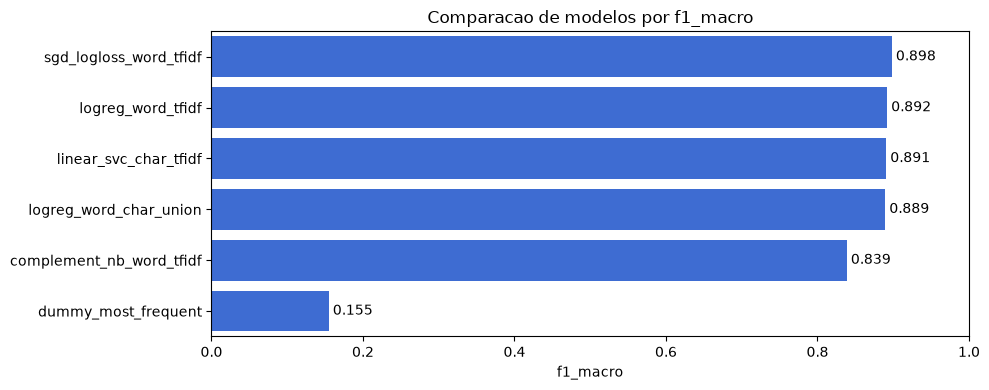

In [15]:
experiment_config = ExperimentConfig(
    text_col="Body_clean",
    target_col="Category",
    id_col="Id",
    random_state=42,
    validation_size=0.2,
    cv_folds=5,
    scoring="f1_macro",
    output_dir=str(OUTPUT_DIR),
)

classical_models = build_sparse_model_zoo(random_state=experiment_config.random_state)
results_df, fitted_models = evaluate_model_zoo(
    train_clean,
    models=classical_models,
    config=experiment_config,
)

ranked = rank_results(results_df, metric="f1_macro")
display(ranked)
plot_metric_comparison(results_df, metric="f1_macro")

results_path = save_results_table(results_df, OUTPUT_DIR / "model_results_holdout.csv")
print("Resultados holdout salvos em:", results_path)


In [16]:
top_model_names = ranked.head(3)["model"].tolist()
cv_results = cross_validate_best_models(
    train_clean,
    model_names=top_model_names,
    models=build_sparse_model_zoo(random_state=experiment_config.random_state),
    config=experiment_config,
)

cv_results_path = OUTPUT_DIR / "model_results_cv_top3.csv"
cv_results.to_csv(cv_results_path, index=False)

display(cv_results)
print("Resultados de validação cruzada salvos em:", cv_results_path)


c:\Users\lorenzo.chiachio\Documents\Pessoal\BCC\7-semestre\pln\Projeto\COURT\template-implementacao\.venv\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\lorenzo.chiachio\Documents\Pessoal\BCC\7-semestre\pln\Projeto\COURT\template-implementacao\.venv\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\lorenzo.chiachio\Documents\Pessoal\BCC\7-semestre\pln\Projeto\COURT\template-implementacao\.venv\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warni

,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std
0,sgd_logloss_word_tfidf,0.920047,0.004517,0.902755,0.007641,0.919957,0.004516
1,linear_svc_char_tfidf,0.913580,0.005823,0.897519,0.007443,0.914132,0.005745
2,logreg_word_tfidf,0.905448,0.004891,0.891621,0.006605,0.907320,0.004822


Resultados de validação cruzada salvos em: c:\Users\lorenzo.chiachio\Documents\Pessoal\BCC\7-semestre\pln\Projeto\COURT\template-implementacao\outputs\model_results_cv_top3.csv


In [ ]:
best_name, best_holdout_model = select_best_model(results_df, fitted_models, metric="f1_macro")
print("Melhor modelo clássico no holdout:", best_name)

best_info = fitted_models[best_name]
plot_confusion_matrix(best_info["y_valid"], best_info["y_pred"], labels=[0, 1, 2, 3, 4])
display(classification_report_frame(best_info["classification_report"]))

In [ ]:
audit_models = build_sparse_model_zoo(random_state=experiment_config.random_state)
label_audit_model_name = "logreg_word_tfidf" if "logreg_word_tfidf" in audit_models else best_name

print("Modelo usado para auditoria e pseudo-rotulagem:", label_audit_model_name)

label_issues = detect_label_issues_with_cv(
    train_clean,
    audit_models[label_audit_model_name],
    config=experiment_config,
    min_confidence=0.85,
)
label_issues_path = OUTPUT_DIR / "potential_label_issues.csv"
label_issues.to_csv(label_issues_path, index=False)

label_audit_model = fit_model_on_full_train(
    train_clean,
    audit_models[label_audit_model_name],
    config=experiment_config,
)

unlabeled_clean = add_clean_text_column(train_unlabeled, config=preprocess_config)
pseudo_labeled, pseudo_report = pseudo_label_unlabeled_samples(
    unlabeled_clean,
    label_audit_model,
    config=experiment_config,
    min_confidence=0.92,
)
pseudo_labeled_path = OUTPUT_DIR / "pseudo_labeled_samples.csv"
pseudo_labeled.to_csv(pseudo_labeled_path, index=False)

train_modeling = build_training_set_with_pseudo_labels(
    train_clean,
    pseudo_labeled,
    label_issues=label_issues,
    config=experiment_config,
    correction_min_confidence=0.97,
)

summary_audit = pd.DataFrame(
    [
        {
            "rotuladas_originais": len(train_clean),
            "sem_rotulo_disponiveis": len(train_unlabeled),
            "pseudo_rotuladas_usadas": pseudo_report["selected"],
            "possiveis_rotulos_ruidosos": len(label_issues),
            "correcoes_automaticas": int((train_modeling["LabelAuditAction"] == "auto_corrected").sum()),
            "total_treino_final": len(train_modeling),
        }
    ]
)
display(summary_audit)
print("Auditoria salva em:", label_issues_path)
print("Pseudo-rótulos salvos em:", pseudo_labeled_path)

if not label_issues.empty:
    display(label_issues.head(10))
if not pseudo_labeled.empty:
    display(pseudo_labeled[["Id", "Category", "PseudoConfidence", "PseudoConfidenceMargin"]].head(10))

final_classical_models = build_sparse_model_zoo(random_state=experiment_config.random_state)
final_classical_model = fit_model_on_full_train(
    train_modeling,
    final_classical_models[best_name],
    config=experiment_config,
)

classical_model_path = save_model(final_classical_model, MODEL_DIR / f"{best_name}.joblib")
submission_classical = generate_submission(
    final_classical_model,
    test_clean,
    output_path=OUTPUT_DIR / "submission.csv",
    text_col="Body_clean",
    id_col="Id",
)

print("Modelo clássico salvo em:", classical_model_path)
print("Submissão clássica salva em:", OUTPUT_DIR / "submission.csv")
display(submission_classical.head())

## 6. Modelos profundos de categorização

Nesta etapa, um SentenceTransformer multilíngue converte cada documento em uma representação densa. Como os textos jurídicos podem ultrapassar a janela do modelo, cada documento é dividido em trechos sobrepostos; os vetores desses trechos são agregados por média.

Classificadores supervisionados são comparados sobre os embeddings das amostras originalmente rotuladas. O melhor é reajustado com o conjunto de treinamento ampliado e usado para gerar uma submissão independente.


In [ ]:
embedding_model_name = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
embedding_batch_size = max(1, runtime_profile["transformer_batch_size"] * 2)

embeddings_train = build_chunked_sentence_embedding_matrix(
    train_modeling["Body_clean"],
    model_name=embedding_model_name,
    batch_size=embedding_batch_size,
    device=runtime_profile["device"],
    max_words=220,
    overlap_words=40,
    pooling="mean",
)
embeddings_test = build_chunked_sentence_embedding_matrix(
    test_clean["Body_clean"],
    model_name=embedding_model_name,
    batch_size=embedding_batch_size,
    device=runtime_profile["device"],
    max_words=220,
    overlap_words=40,
    pooling="mean",
)

embeddings_labeled_only = embeddings_train[: len(train_clean)]
embedding_results, embedding_models = evaluate_embedding_classifier(
    train_clean,
    embeddings_labeled_only,
    config=experiment_config,
)
display(embedding_results)

In [ ]:
best_embedding_name = embedding_results.iloc[0]["model"]
final_embedding_model = fit_embedding_classifier_on_full_train(
    train_modeling,
    embeddings_train,
    model_name=best_embedding_name,
    config=experiment_config,
)

embedding_model_path = save_model(final_embedding_model, MODEL_DIR / f"{best_embedding_name}.joblib")
submission_embeddings = generate_embedding_submission(
    final_embedding_model,
    embeddings_test,
    test_clean["Id"],
    output_path=OUTPUT_DIR / "submission_embeddings.csv",
)

print("Modelo de embeddings salvo em:", embedding_model_path)
print("Submissão de embeddings salva em:", OUTPUT_DIR / "submission_embeddings.csv")
display(submission_embeddings.head())

## 7. Adaptação de modelos de linguagem

A adaptação supervisionada ajusta um modelo de linguagem pré-treinado à classificação jurídica. O pipeline apresenta os candidatos disponíveis e usa o perfil automático de execução para selecionar modelo, dispositivo, tamanho de lote, comprimento máximo, precisão numérica e, quando aplicável, LoRA ou quantização.

O treinamento usa pesos de classe e seleciona o melhor checkpoint por `f1_macro`. Ao final, o modelo adaptado produz `submission_transformer.csv`.


In [ ]:
display(transformer_candidate_models())
print("Ambiente detectado para o fine-tuning:")
display(pd.DataFrame([runtime_profile["environment"]]))

In [ ]:
trainer = fine_tune_transformer_classifier(
    train_modeling,
    model_name=runtime_profile["recommended_transformer"],
    config=experiment_config,
    num_train_epochs=runtime_profile["transformer_epochs"],
    learning_rate=runtime_profile["transformer_learning_rate"],
    per_device_train_batch_size=runtime_profile["transformer_batch_size"],
    max_length=runtime_profile["transformer_max_length"],
    output_dir=str(OUTPUT_DIR / "bertimbau"),
    use_class_weights=True,
    use_lora=runtime_profile["use_lora"],
    quantization_4bit=runtime_profile["quantization_4bit"],
    device=runtime_profile["device"],
)

submission_transformer = generate_transformer_submission(
    trainer,
    test_clean,
    output_path=OUTPUT_DIR / "submission_transformer.csv",
    text_col="Body_clean",
    id_col="Id",
    max_length=runtime_profile["transformer_max_length"],
)

print("Submissão Transformer salva em:", OUTPUT_DIR / "submission_transformer.csv")
display(submission_transformer.head())

## 8. Análise de resultados

A análise deve considerar mais do que uma única pontuação. Para os modelos clássicos, o notebook registra resultados de holdout, validação cruzada, matriz de confusão e relatório por classe. Para embeddings e Transformers, as submissões permitem comparar o desempenho externo no leaderboard.

Os principais artefatos são:

- `model_results_holdout.csv`: comparação inicial dos modelos clássicos;
- `model_results_cv_top3.csv`: estabilidade dos três melhores modelos;
- `potential_label_issues.csv`: exemplos suspeitos identificados pela auditoria;
- `pseudo_labeled_samples.csv`: pseudo-rótulos aceitos e respectivas confianças;
- `submission.csv`: previsão do melhor modelo clássico;
- `submission_embeddings.csv`: previsão baseada em embeddings densos;
- `submission_transformer.csv`: previsão do modelo de linguagem adaptado.

A escolha final deve combinar `f1_macro`, estabilidade entre divisões, desempenho por classe, custo computacional e resultado no leaderboard.


In [ ]:
print("Arquivos gerados em outputs/:")
for path in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", path)

print("Modelos salvos em models/:")
for path in sorted(MODEL_DIR.glob("*.joblib")):
    print("-", path)

### Possíveis extensões

Como próximos ciclos, podem ser comparados diferentes tratamentos de stopwords e lematização, limiares de auditoria e pseudo-rotulagem, estratégias de chunking, hiperparâmetros de TF-IDF, embeddings jurídicos e modelos de linguagem de contexto longo. A análise manual dos erros entre ARE e RE também tende a oferecer pistas úteis para novas features e ajustes.
